# MGMT298D: Science and Strategy of AI
### Week 4B - Q-Learning
### Application: Dynamic Pricing with Inventory

## Import Libraries and Setup

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## The Pricing Game Environment

Unlike bandits, Q-learning considers **state**: the optimal action depends on the situation.

Here, we have a seasonal inventory problem:
- We have limited inventory to sell before the season ends
- State = (inventory level, time remaining)
- The optimal price **changes** depending on the state:
  - High inventory + late season → must discount to clear stock
  - Low inventory → can charge premium (scarcity)
- Unsold inventory at season end is penalized

In [5]:
PRICES = [5, 10, 15, 20, 25]

class PricingGame:
    """Seasonal pricing game where optimal price depends on state."""
    
    def __init__(self, inventory=15, periods=20):
        self.start_inv = inventory
        self.total_periods = periods
        self.reset()
    
    def reset(self):
        self.inventory = self.start_inv
        self.periods_left = self.total_periods
        return self.get_state()
    
    def get_state(self):
        inv = "high" if self.inventory > 8 else "low"
        time = "early" if self.periods_left > 10 else "late"
        return (inv, time)
    
    def step(self, price_index):
        if self.periods_left <= 0 or self.inventory <= 0:
            return self.get_state(), 0, True
        
        inv, time = self.get_state()
        
        # Conversion rates vary by state - this is the key!
        # Each state has different optimal pricing
        rates = {
            ("high", "early"): [0.85, 0.65, 0.35, 0.12, 0.04],  # Best: $10
            ("high", "late"):  [0.92, 0.80, 0.55, 0.22, 0.07],  # Best: $15
            ("low", "early"):  [0.45, 0.50, 0.48, 0.38, 0.22],  # Best: $20 (scarcity!)
            ("low", "late"):   [0.65, 0.70, 0.68, 0.52, 0.32],  # Best: $20 (scarcity + urgency!)
        }
        
        rate = rates[(inv, time)][price_index]
        sold = np.random.random() < rate
        revenue = PRICES[price_index] if sold else 0
        
        if sold:
            self.inventory -= 1
        self.periods_left -= 1
        
        done = self.periods_left <= 0 or self.inventory <= 0
        
        # Penalty for unsold inventory at end of season
        if done and self.inventory > 0:
            revenue -= self.inventory * 4
        
        return self.get_state(), revenue, done

print("States: (inventory, time)")
print("  - high/early: Plenty of stock, plenty of time")
print("  - high/late:  Too much stock, running out of time!")
print("  - low/early:  Low stock, can charge premium")
print("  - low/late:   Scarcity + urgency = highest prices")

States: (inventory, time)
  - high/early: Plenty of stock, plenty of time
  - high/late:  Too much stock, running out of time!
  - low/early:  Low stock, can charge premium
  - low/late:   Scarcity + urgency = highest prices


## Q-Learning Algorithm

In [7]:
def run_qlearning(n_episodes, learning_rate=0.15, discount=0.9):
    """Train a Q-learning agent."""
    
    states = [("high", "early"), ("high", "late"), ("low", "early"), ("low", "late")]
    Q = {s: [0.0] * 5 for s in states}
    
    episode_revenues = []
    
    for episode in range(n_episodes):
        # Epsilon decays: explore more early, exploit more later
        epsilon = max(0.05, 1.0 - episode / (n_episodes * 0.7))
        
        game = PricingGame()
        state = game.reset()
        total_revenue = 0
        
        while True:
            # Choose action (epsilon-greedy)
            if np.random.random() < epsilon:
                action = np.random.randint(5)
            else:
                action = Q[state].index(max(Q[state]))
            
            # Take action
            next_state, revenue, done = game.step(action)
            total_revenue += revenue
            
            # Q-learning update
            old_value = Q[state][action]
            target = revenue if done else revenue + discount * max(Q[next_state])
            Q[state][action] = old_value + learning_rate * (target - old_value)
            
            state = next_state
            if done:
                break
        
        episode_revenues.append(total_revenue)
    
    return episode_revenues, Q

revenues, Q_table = run_qlearning(1500)
print(f"Training complete: {len(revenues)} episodes")

Training complete: 1500 episodes


## Learning Curve

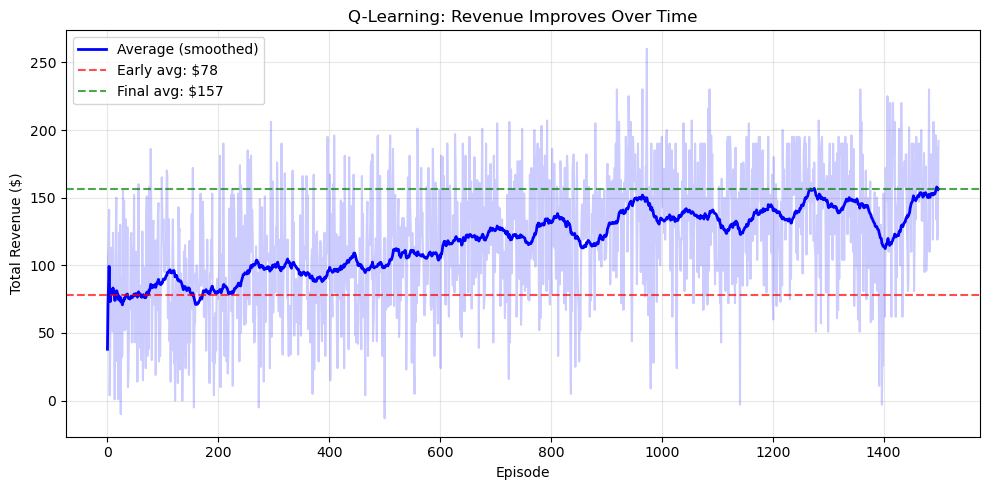

Average revenue (first 50 episodes):  $78.1
Average revenue (last 50 episodes):   $156.7
Improvement: $78.6 (101% increase)


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

window = 50
smoothed = [np.mean(revenues[max(0, i-window):i+1]) for i in range(len(revenues))]

ax.plot(revenues, alpha=0.2, color="blue")
ax.plot(smoothed, color="blue", linewidth=2, label="Average (smoothed)")
ax.axhline(y=np.mean(revenues[:50]), color="red", linestyle="--", alpha=0.7, 
           label=f"Early avg: ${np.mean(revenues[:50]):.0f}")
ax.axhline(y=np.mean(revenues[-50:]), color="green", linestyle="--", alpha=0.7, 
           label=f"Final avg: ${np.mean(revenues[-50:]):.0f}")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Revenue ($)")
ax.set_title("Q-Learning: Revenue Improves Over Time")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

improvement = np.mean(revenues[-50:]) - np.mean(revenues[:50])
pct = improvement / np.mean(revenues[:50]) * 100
print(f"Average revenue (first 50 episodes):  ${np.mean(revenues[:50]):.1f}")
print(f"Average revenue (last 50 episodes):   ${np.mean(revenues[-50:]):.1f}")
print(f"Improvement: ${improvement:.1f} ({pct:.0f}% increase)")

## Learned Policy: Best Price by Situation

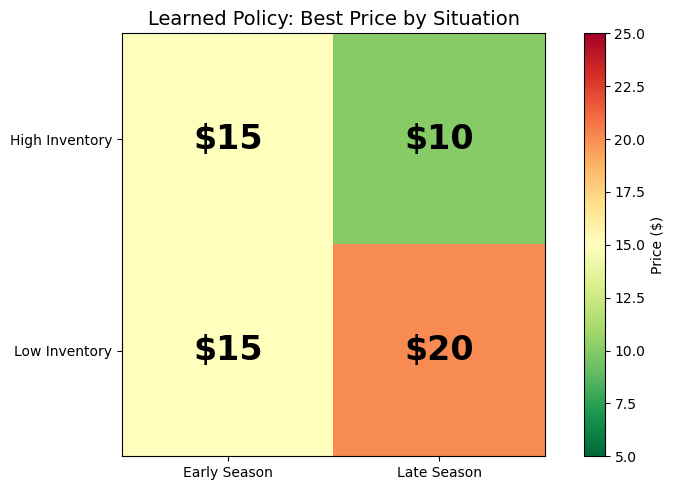

Policy interpretation:
  - Low inventory → charge premium (scarcity)
  - High inventory + late → discount to clear stock


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

inv_levels = ["high", "low"]
time_levels = ["early", "late"]

policy_grid = []
for inv in inv_levels:
    row = []
    for time in time_levels:
        best_action = Q_table[(inv, time)].index(max(Q_table[(inv, time)]))
        row.append(PRICES[best_action])
    policy_grid.append(row)

im = ax.imshow(policy_grid, cmap="RdYlGn_r", vmin=5, vmax=25)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Early Season", "Late Season"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["High Inventory", "Low Inventory"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"${policy_grid[i][j]}", ha="center", va="center", 
                fontsize=24, fontweight="bold")

plt.title("Learned Policy: Best Price by Situation", fontsize=14)
plt.colorbar(im, label="Price ($)")
plt.tight_layout()
plt.show()

print("Policy interpretation:")
print("  - Low inventory → charge premium (scarcity)")
print("  - High inventory + late → discount to clear stock")

## Compare: Random vs Learned Policy

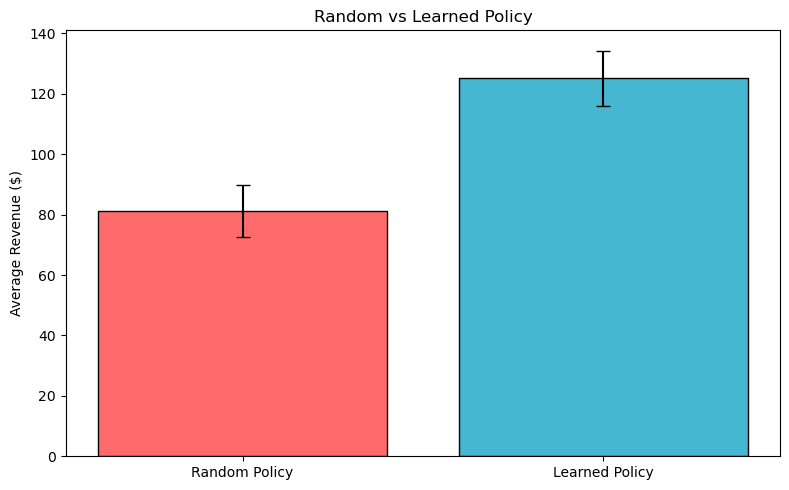

Random policy:  $81.2
Learned policy: $125.1
Improvement: $43.9 (54% better)


In [13]:
def run_learned_policy(Q, n_episodes):
    """Run learned policy with no exploration."""
    revenues = []
    for _ in range(n_episodes):
        game = PricingGame()
        state = game.reset()
        total = 0
        while True:
            action = Q[state].index(max(Q[state]))
            state, revenue, done = game.step(action)
            total += revenue
            if done:
                break
        revenues.append(total)
    return revenues

def run_random_policy(n_episodes):
    """Run random policy."""
    revenues = []
    for _ in range(n_episodes):
        game = PricingGame()
        state = game.reset()
        total = 0
        while True:
            action = np.random.randint(5)
            state, revenue, done = game.step(action)
            total += revenue
            if done:
                break
        revenues.append(total)
    return revenues

learned_revenues = run_learned_policy(Q_table, 500)
random_revenues = run_random_policy(500)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(["Random Policy", "Learned Policy"], 
       [np.mean(random_revenues), np.mean(learned_revenues)],
       yerr=[np.std(random_revenues)/5, np.std(learned_revenues)/5],
       color=["#ff6b6b", "#45b7d1"], edgecolor="k", capsize=5)
ax.set_ylabel("Average Revenue ($)")
ax.set_title("Random vs Learned Policy")

plt.tight_layout()
plt.show()

improvement = np.mean(learned_revenues) - np.mean(random_revenues)
pct = improvement / np.mean(random_revenues) * 100
print(f"Random policy:  ${np.mean(random_revenues):.1f}")
print(f"Learned policy: ${np.mean(learned_revenues):.1f}")
print(f"Improvement: ${improvement:.1f} ({pct:.0f}% better)")

## Effect of Learning Rate

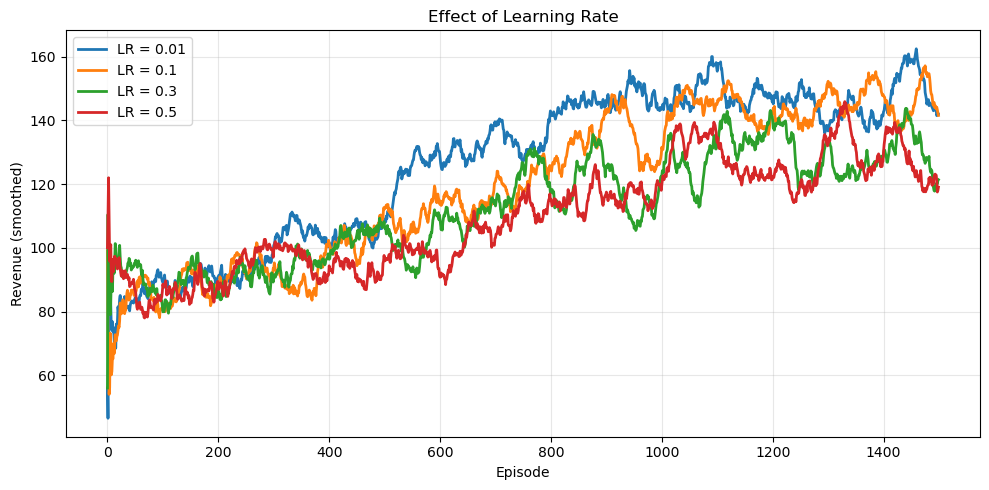

In [15]:
learning_rates = [0.01, 0.1, 0.3, 0.5]

fig, ax = plt.subplots(figsize=(10, 5))

for lr in learning_rates:
    revs, _ = run_qlearning(1500, learning_rate=lr)
    smoothed = [np.mean(revs[max(0, i-50):i+1]) for i in range(len(revs))]
    ax.plot(smoothed, label=f"LR = {lr}", linewidth=2)

ax.set_xlabel("Episode")
ax.set_ylabel("Revenue (smoothed)")
ax.set_title("Effect of Learning Rate")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Effect of Discount Factor

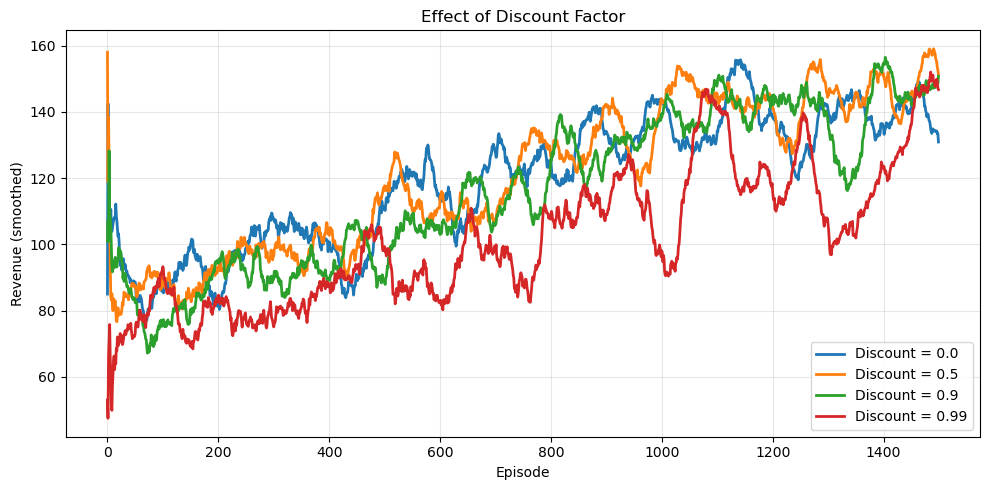

In [17]:
discounts = [0.0, 0.5, 0.9, 0.99]

fig, ax = plt.subplots(figsize=(10, 5))

for d in discounts:
    revs, _ = run_qlearning(1500, discount=d)
    smoothed = [np.mean(revs[max(0, i-50):i+1]) for i in range(len(revs))]
    ax.plot(smoothed, label=f"Discount = {d}", linewidth=2)

ax.set_xlabel("Episode")
ax.set_ylabel("Revenue (smoothed)")
ax.set_title("Effect of Discount Factor")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()